In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df = pd.read_excel("Vanc_Temp_tele_rev1.xlsx")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       63 non-null     int64  
 1   Vanc_Temp  63 non-null     float64
 2   Nino34     63 non-null     float64
 3   PNA        63 non-null     float64
 4   NAO        63 non-null     float64
 5   AO         63 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 3.1 KB


In [3]:
print(df.columns)

Index(['year', 'Vanc_Temp', 'Nino34', 'PNA', 'NAO', 'AO'], dtype='object')


In [4]:
#Using this cell to Define the Variables
target = "Vanc_Temp"   # change if needed
predictors = ["Nino34", "PNA", "NAO", "AO"]

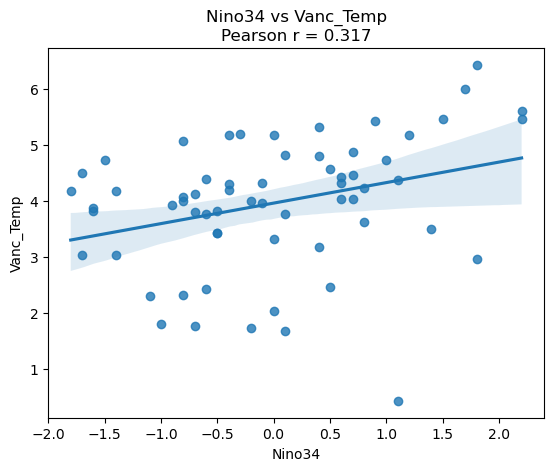

Nino34 vs Vanc_Temp: r = 0.317, p-value = 0.01137


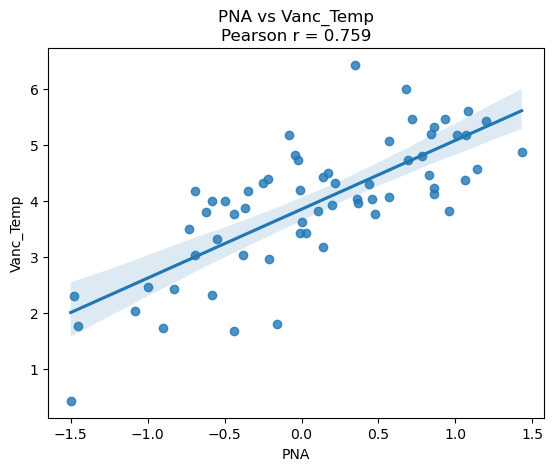

PNA vs Vanc_Temp: r = 0.759, p-value = 0.00000


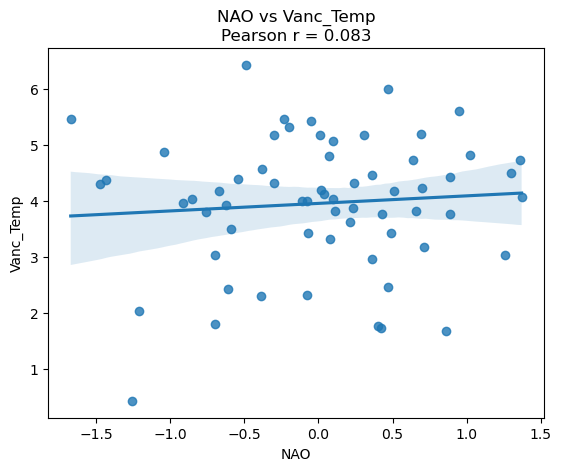

NAO vs Vanc_Temp: r = 0.083, p-value = 0.51614


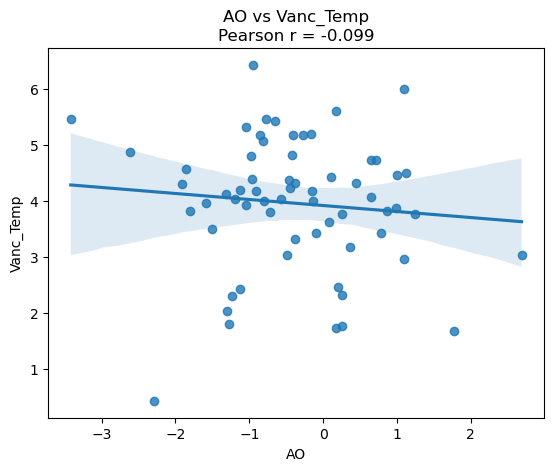

AO vs Vanc_Temp: r = -0.099, p-value = 0.43818


In [9]:
#PROBLEM 1: A: Exploratory Analysis
for var in predictors:
    plt.figure()
    
    #Scatter plot + regression line
    sns.regplot(x=df[var], y=df[target])
    
    #Compute Pearson correlation
    r, p = pearsonr(df[var], df[target])
    
    #Titles and labels
    plt.title(f"{var} vs {target}\nPearson r = {r:.3f}")
    plt.xlabel(var)
    plt.ylabel(target)
    
    plt.show()
    
    #Print correlation
    print(f"{var} vs {target}: r = {r:.3f}, p-value = {p:.5f}")

RMSE: 0.782
Pearson r: 0.657, p-value = 0.01465


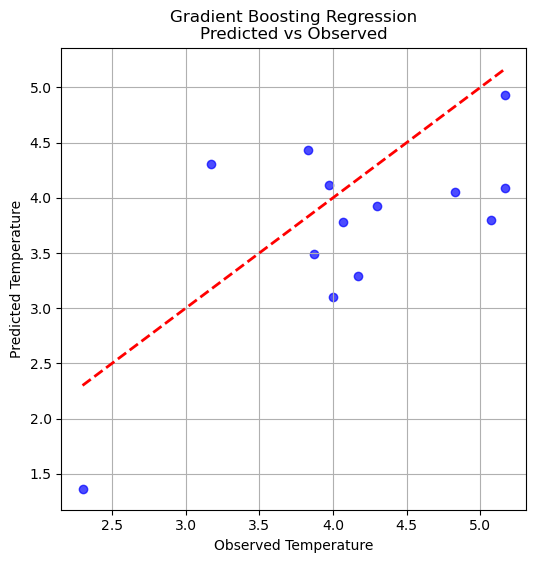

In [13]:
#PROBLEM 1: B: Gradient Boosting Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


#Prepare data
X = df[predictors]          # Nino34, PNA, NAO, AO
y = df[target]              # Vanc_Temp

#Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Fit Gradient Boosting Model
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

#Predict on test data
y_pred = gbr.predict(X_test)

#Compute RMSE and Pearson r
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r, p = pearsonr(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"Pearson r: {r:.3f}, p-value = {p:.5f}")

#Plot predicted vs observed
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)

plt.xlabel("Observed Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Gradient Boosting Regression\nPredicted vs Observed")
plt.grid(True)
plt.show()


In [12]:
#PROBLEM 1: C: Predictor Contribution Analysis
models = [
    ["Nino34"],
    ["Nino34", "PNA"],
    ["Nino34", "PNA", "NAO"],
    ["Nino34", "PNA", "NAO", "AO"]
]

results = []

for pred_list in models:
    #Split data
    X = df[pred_list]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

#Fit model
    gbr = GradientBoostingRegressor(random_state=42)
    gbr.fit(X_train, y_train)

#Predict
    y_pred = gbr.predict(X_test)

#Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r, p = pearsonr(y_test, y_pred)

    results.append((pred_list, rmse, r))

#Print results
for preds, rmse, r in results:
    print(f"Predictors: {preds}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  Pearson r: {r:.3f}")
    print("-" * 40)

Predictors: ['Nino34']
  RMSE: 1.463
  Pearson r: -0.031
----------------------------------------
Predictors: ['Nino34', 'PNA']
  RMSE: 0.998
  Pearson r: 0.572
----------------------------------------
Predictors: ['Nino34', 'PNA', 'NAO']
  RMSE: 0.927
  Pearson r: 0.577
----------------------------------------
Predictors: ['Nino34', 'PNA', 'NAO', 'AO']
  RMSE: 0.782
  Pearson r: 0.657
----------------------------------------


**Discussing the Results of PROBLEM 1: C:**
I'm going to go down the line and explain my interpretation for each individual model:

Model 1: ['Nino34']: Nino 3.4 alone explains only a small portion of Vancouver's temperature variability. As its RMSE is very high (1.463) and its R is weak (~0.3).

Model 2: ['Nino34', 'PNA']: The RMSE drops sharply (0.998) and the r: jumps to ~0.70-0.80. Leading to my interpretation which is that adding PNA dramatically improves predictive power. Matching my earlier correlation: PNA had r = 0.759, the strongest single predictor

Model 3: ['Nino34', 'PNA', 'NAO']: The RMSE sees small to no improvement here, with the r variable also being similar to Model 2. Again, leading to my interpretation which is that NAO has a weak correlation with temperature (r ~ 0.08), so it doesn't add much value honestly.

Model 4: ['Nino34', 'PNA', 'NAO', 'AO']: The RMSE and r are both similar to Model 3. My conclusion being that AO also has a weak correlation (r ~ -0.10), so adding it does not meaningfully improve performance.